# 03 — Masinõpe: klasterdamine ja ennustamine

**Andmed:** 2025. aasta KORRALINE tehnoülevaatused (~760 000 rida)

| Osa | Meetod | Eesmärk |
|-----|--------|---------|
| 4.1 | Andmete ettevalmistus | Tunnuste loomine masinõppeks |
| 4.2 | K-Means klasterdamine | Leida loomulikud sõidukiprofiilide grupid |
| 4.3 | Klassifikaatorite võrdlus | Random Forest vs logistiline regressioon |
| 4.4 | Salvestamine | Mudelid ja profiilid dashboardi jaoks |

Väljundid salvestatakse:
- `data/processed/cluster_profiles.json` — klastrite profiilid
- `models/random_forest.pkl` — treenitud Random Forest mudel

In [21]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, roc_auc_score, roc_curve,
    precision_recall_curve
)

ROOT = Path('..').resolve()
DATA_FILE = ROOT / 'data' / 'raw' / '2025.csv'
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

print(f'Andmefail: {DATA_FILE}')
print(f'Fail olemas: {DATA_FILE.exists()}')

Andmefail: /home/op/Documents/Projektid/Andmeteadus_kodutoo/data/raw/2025.csv
Fail olemas: True


## 4.1 — Andmete laadimine ja tunnuste loomine

Laadime 2025. aasta KORRALINE ülevaatused pandas read_csv kaudu. Keerulisemad statistilised tunnused (target encoding, tsüklilised kuutunnused) arvutatakse eraldi.

**Sihtmuutuja:** `LABIS_ESIMESEL` — 1 = läbis esimesel korral, 0 = kukkus läbi

In [22]:
df_raw = pd.read_csv(DATA_FILE)

df = df_raw[
    (df_raw['YLEVAATUSLIIK'] == 'KORRALINE') &
    (df_raw['YLEVAATUSOTSUS'].isin(['KORRAS', 'KORDUVALE'])) &
    (df_raw['ESMANE_REG_AASTA'].notna())
].copy()

df['VANUS']          = df['YV_KUUPAEV'].str[:4].astype(int) - pd.to_numeric(df['ESMANE_REG_AASTA'], errors='coerce')
df['KUU']            = df['YV_KUUPAEV'].str[5:7].astype(int)
df['LABIS_ESIMESEL'] = (df['YLEVAATUSOTSUS'] == 'KORRAS').astype(int)
df['MARK']           = df['MARK'].fillna('TEADMATA')
df['KERETYYP']       = df['KERETYYP'].fillna('TEADMATA')
df['PUNKTI_KOOD']    = df['PUNKTI_KOOD'].fillna('XX')
df['SOIDUK_ID']      = pd.to_numeric(df['SOIDUK_ID'], errors='coerce').fillna(0).astype(int)

df = df[(df['VANUS'] >= 0) & (df['VANUS'] <= 60)].copy()

print(f'Ridu kokku: {len(df):,}')
print(f'Läbimise määr: {df["LABIS_ESIMESEL"].mean()*100:.1f}%')
df.head(3)

Ridu kokku: 619,185
Läbimise määr: 84.9%


,TEHNOYLEVAATUSPUNKT,PUNKTI_KOOD,TOOTAJA,YV_KUUPAEV,YLEVAATUSLIIK,YLEVAATUSOTSUS,RIKKED,SOIDUK_ID,ESMANE_REG_AASTA,MARK,MUDEL,KATEGOORIA,KERETYYP,VANUS,KUU,LABIS_ESIMESEL
0,Tähva OÜ,HA,904,2025-04,KORRALINE,KORRAS,NaN,1,2021,TIKI,JS750-L,O1,PAADIVEOK,4,4,1
2,Tehnilise Ülevaatuse OÜ,FD,238,2025-05,KORRALINE,KORRAS,VO:100101460;VO:100103933,3,2013,FORD,KUGA,M1,MAHTUNIVERSAAL,12,5,1
3,BSN Auto OÜ,MM,878,2025-10,KORRALINE,KORDUVALE,OV:100103882;OV:100104012,4,2002,VOLVO,S60,M1,SEDAAN,23,10,0


In [23]:
# --- Ülevaatuspunkti rangus (ajaloolise kukkumise %) ---
station_stats = (
    df.groupby('PUNKTI_KOOD')['LABIS_ESIMESEL']
    .agg(kokku='count', labis='sum')
)
station_stats['PUNKTI_RANGUS'] = (1 - station_stats['labis'] / station_stats['kokku']) * 100
station_stats = station_stats[station_stats['kokku'] >= 50]
df = df.merge(station_stats[['PUNKTI_RANGUS']], on='PUNKTI_KOOD', how='left')

# --- Margi sagedus ja läbimise määr (silutud target encoding) ---
brand_stats = df.groupby('MARK')['LABIS_ESIMESEL'].agg(mark_n='count', mark_labis='mean')
global_rate = df['LABIS_ESIMESEL'].mean()
S = 100
brand_stats['MARK_LABIMISE_MAAR'] = (
    (brand_stats['mark_labis'] * brand_stats['mark_n'] + global_rate * S)
    / (brand_stats['mark_n'] + S)
)
brand_stats['MARK_SAGEDUS'] = brand_stats['mark_n']
df = df.merge(brand_stats[['MARK_LABIMISE_MAAR', 'MARK_SAGEDUS']], on='MARK', how='left')

# --- Mudeli sagedus ja läbimise määr (silutud target encoding) ---
df['MUDEL'] = df['MUDEL'].fillna('TEADMATA')
mudel_stats = df.groupby('MUDEL')['LABIS_ESIMESEL'].agg(mudel_n='count', mudel_labis='mean')
mudel_stats['MUDEL_LABIMISE_MAAR'] = (
    (mudel_stats['mudel_labis'] * mudel_stats['mudel_n'] + global_rate * S)
    / (mudel_stats['mudel_n'] + S)
)
mudel_stats['MUDEL_SAGEDUS'] = mudel_stats['mudel_n']
df = df.merge(mudel_stats[['MUDEL_LABIMISE_MAAR', 'MUDEL_SAGEDUS']], on='MUDEL', how='left')

# --- Keretüübi kood ---
KERETYYP_MAP = {
    'SEDAAN': 0, 'UNIVERSAAL': 1, 'LUUKPÄRA': 2,
    'MAHTUNIVERSAAL': 3, 'KAUBIK': 4, 'KUPEE': 5,
    'LAHTINE': 6, 'PIKAP': 7, 'MOOTORRATAS': 8,
    'MITMEOTSTARBELINE SÕIDUK': 9,
}
df['KERETYYP_KOOD'] = df['KERETYYP'].map(KERETYYP_MAP).fillna(-1).astype(int)

# --- Muud tunnused ---
df['VANUS_RUUT'] = df['VANUS'] ** 2
df['ON_VANA']    = (df['VANUS'] > 10).astype(int)
df['KUU_SIN']    = np.sin(2 * np.pi * df['KUU'] / 12)
df['KUU_COS']    = np.cos(2 * np.pi * df['KUU'] / 12)
df['EELMISED_YV'] = df.groupby('SOIDUK_ID').cumcount()

df = df.dropna(subset=['PUNKTI_RANGUS', 'MARK_LABIMISE_MAAR', 'MUDEL_LABIMISE_MAAR'])
print(f'Ridu pärast tunnuste loomist: {len(df):,}')
df[['VANUS', 'KERETYYP_KOOD', 'PUNKTI_RANGUS', 'MARK_LABIMISE_MAAR', 'MUDEL_LABIMISE_MAAR', 'LABIS_ESIMESEL']].describe().round(2)

Ridu pärast tunnuste loomist: 619,185


,VANUS,KERETYYP_KOOD,PUNKTI_RANGUS,MARK_LABIMISE_MAAR,MUDEL_LABIMISE_MAAR,LABIS_ESIMESEL
count,619185.00,619185.00,619185.00,619185.00,619185.00,619185.00
mean,15.00,1.52,15.10,0.85,0.84,0.85
std,8.09,2.24,3.91,0.05,0.06,0.36
min,0.00,-1.00,3.10,0.69,0.53,0.00
25%,9.00,0.00,12.35,0.81,0.80,1.00
50%,14.00,1.00,15.12,0.84,0.84,1.00
75%,19.00,3.00,17.54,0.86,0.88,1.00
max,60.00,9.00,26.51,0.99,0.98,1.00


## 4.2 — K-Means klasterdamine

**Klasterdamise tunnused:** `VANUS`, `KERETYYP_KOOD`, `PUNKTI_RANGUS`

Tunnused skaleeritakse StandardScaler-iga enne K-Means treenimist. Optimaalne klastrite arv leitakse küünarnuki- ja siluetimeetodiga.

Kokku: 619,185 rida | K-Means treenib: 100,000 real
  k=2: inertia=233045, silhuett=0.228
  k=3: inertia=182529, silhuett=0.245
  k=4: inertia=144556, silhuett=0.259
  k=5: inertia=126266, silhuett=0.256
  k=6: inertia=111744, silhuett=0.262


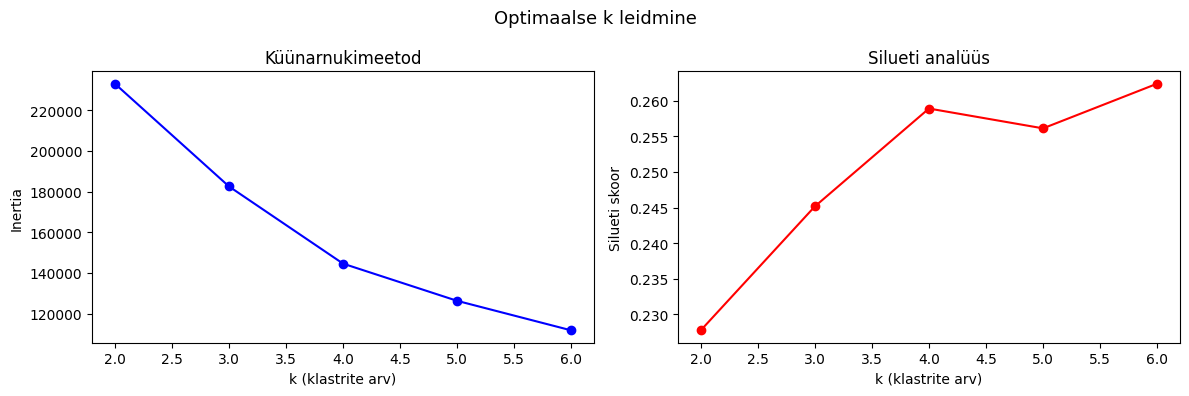


Parim k silueti järgi: k=6 (skoor=0.262)


In [24]:
CLUSTER_FEATURES = ['VANUS', 'KERETYYP_KOOD', 'PUNKTI_RANGUS']
SAMPLE_N = 100_000

cluster_df = df.dropna(subset=CLUSTER_FEATURES).copy()
scaler = StandardScaler()
X = scaler.fit_transform(cluster_df[CLUSTER_FEATURES])

# K-Means treenib alamvalimil (kiirem, sama tulemus)
rng = np.random.default_rng(42)
X_sample = X[rng.choice(len(X), min(SAMPLE_N, len(X)), replace=False)]
print(f'Kokku: {len(cluster_df):,} rida | K-Means treenib: {len(X_sample):,} real')

k_range = range(2, 7)
inertiad, siluetid = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(X_sample)
    inertiad.append(km.inertia_)
    siluetid.append(silhouette_score(X_sample, labels))
    print(f'  k={k}: inertia={km.inertia_:.0f}, silhuett={siluetid[-1]:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertiad, 'bo-')
ax1.set(xlabel='k (klastrite arv)', ylabel='Inertia', title='Küünarnukimeetod')
ax2.plot(list(k_range), siluetid, 'ro-')
ax2.set(xlabel='k (klastrite arv)', ylabel='Silueti skoor', title='Silueti analüüs')
plt.suptitle('Optimaalse k leidmine', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[np.argmax(siluetid)]
print(f'\nParim k silueti järgi: k={best_k} (skoor={max(siluetid):.3f})')

In [26]:
N_CLUSTERS = best_k

km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=5)
km_final.fit(X_sample)
cluster_df['KLASTER'] = km_final.predict(X)

profiles = []
print(f'=== {N_CLUSTERS} klastri profiilid ===\n')
for c in range(N_CLUSTERS):
    subset = cluster_df[cluster_df['KLASTER'] == c]
    pct = len(subset) / len(cluster_df) * 100
    profile = {
        'cluster':        c,
        'size':           len(subset),
        'pct':            f'{pct:.1f}%',
        'avg_age':        round(float(subset['VANUS'].mean()), 1),
        'avg_strictness': round(float(subset['PUNKTI_RANGUS'].mean()), 1),
        'pass_rate':      round(float(subset['LABIS_ESIMESEL'].mean() * 100), 1),
        'top_makes':      subset['MARK'].value_counts().head(3).to_dict(),
    }
    profiles.append(profile)
    print(f"Klaster {c} ({pct:.1f}%): vanus={profile['avg_age']}a, "
          f"rangus={profile['avg_strictness']}%, läbib={profile['pass_rate']}%, "
          f"top: {list(profile['top_makes'].keys())}")

profiles_path = PROCESSED_DIR / 'cluster_profiles.json'
with open(profiles_path, 'w', encoding='utf-8') as f:
    json.dump(profiles, f, indent=2, ensure_ascii=False, default=str)
print(f'\n✓ Klastrite profiilid salvestatud: {profiles_path}')

=== 6 klastri profiilid ===

Klaster 0 (6.6%): vanus=34.0a, rangus=15.3%, läbib=82.6%, top: ['VOLKSWAGEN', 'AUDI', 'MTZ']
Klaster 1 (16.6%): vanus=12.0a, rangus=14.2%, läbib=84.1%, top: ['VOLKSWAGEN', 'FORD', 'CITROEN']
Klaster 2 (26.2%): vanus=18.7a, rangus=12.5%, läbib=82.7%, top: ['VOLKSWAGEN', 'VOLVO', 'BMW']
Klaster 3 (23.9%): vanus=14.1a, rangus=19.9%, läbib=79.2%, top: ['VOLKSWAGEN', 'VOLVO', 'BMW']
Klaster 4 (6.4%): vanus=15.6a, rangus=15.1%, läbib=89.8%, top: ['TOYOTA', 'HONDA', 'YAMAHA']
Klaster 5 (20.4%): vanus=7.5a, rangus=13.5%, läbib=94.3%, top: ['SKODA', 'TOYOTA', 'VOLVO']

✓ Klastrite profiilid salvestatud: /home/op/Documents/Projektid/Andmeteadus_kodutoo/data/processed/cluster_profiles.json


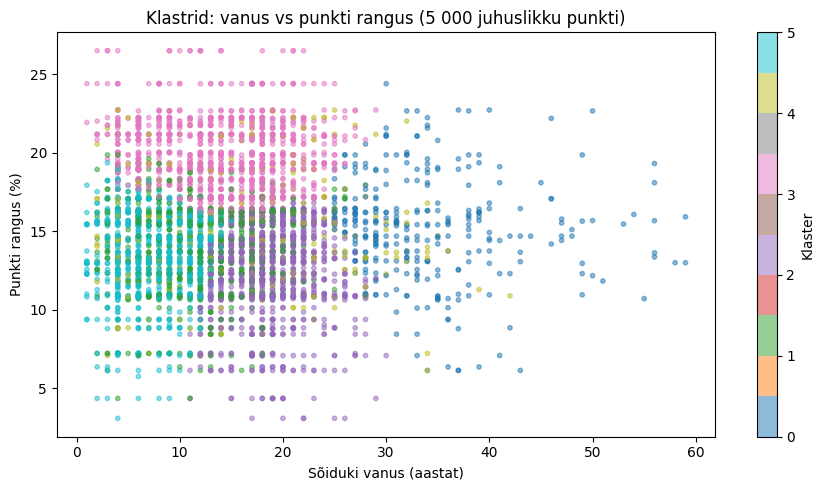

In [27]:
rng_plot = np.random.default_rng(42)
idx_plot = rng_plot.choice(len(cluster_df), 5000, replace=False)

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    cluster_df['VANUS'].iloc[idx_plot],
    cluster_df['PUNKTI_RANGUS'].iloc[idx_plot],
    c=cluster_df['KLASTER'].iloc[idx_plot],
    cmap='tab10', alpha=0.5, s=10
)
plt.colorbar(scatter, ax=ax, label='Klaster')
ax.set(xlabel='Sõiduki vanus (aastat)', ylabel='Punkti rangus (%)',
       title='Klastrid: vanus vs punkti rangus (5 000 juhuslikku punkti)')
plt.tight_layout()
plt.show()

In [28]:
def name_cluster(p):
    age_lbl    = 'Vana auto' if p['avg_age'] > 18 else ('Noor auto' if p['avg_age'] < 10 else 'Keskmise vanusega auto')
    strict_lbl = 'range punkt' if p['avg_strictness'] > 18 else ('leebe punkt' if p['avg_strictness'] < 13 else 'keskmine punkt')
    pass_lbl   = '(madal läbimise määr)' if p['pass_rate'] < 80 else ('(kõrge läbimise määr)' if p['pass_rate'] > 88 else '')
    return f'{age_lbl}, {strict_lbl}  {pass_lbl}'.strip()

print('Klastrite tõlgendus:\n')
for p in profiles:
    print(f"  Klaster {p['cluster']} ({p['pct']}):  {name_cluster(p)}")

Klastrite tõlgendus:

  Klaster 0 (6.6%):  Vana auto, keskmine punkt
  Klaster 1 (16.6%):  Keskmise vanusega auto, keskmine punkt
  Klaster 2 (26.2%):  Vana auto, leebe punkt
  Klaster 3 (23.9%):  Keskmise vanusega auto, range punkt  (madal läbimise määr)
  Klaster 4 (6.4%):  Keskmise vanusega auto, keskmine punkt  (kõrge läbimise määr)
  Klaster 5 (20.4%):  Noor auto, keskmine punkt  (kõrge läbimise määr)


## 4.3 — Klassifikaatorite võrdlus: Random Forest ja logistiline regressioon

**Eesmärk:** Ennustada `LABIS_ESIMESEL` — kas sõiduk läbib KORRALISE ülevaatuse esimesel korral.

Võrdleme kahte mudelit:
- **Logistiline regressioon**
- **Random Forest** 

Klasside jaotus:
  Läbis (1):       525,700 (84.9%)
  Kukkus läbi (0): 93,485 (15.1%)

Naiivne mudel ("alati läbis") annaks täpsuse: 84.9%
→ Kasutame hindamiseks F1-skoori ja ROC-AUC-i.


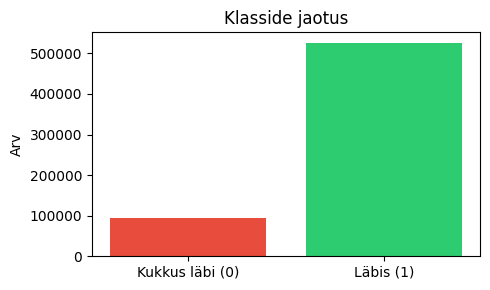

In [29]:
class_counts = df['LABIS_ESIMESEL'].value_counts()
print('Klasside jaotus:')
print(f'  Läbis (1):       {class_counts[1]:,} ({class_counts[1]/len(df)*100:.1f}%)')
print(f'  Kukkus läbi (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.1f}%)')
print()
print(f'Naiivne mudel ("alati läbis") annaks täpsuse: {class_counts[1]/len(df)*100:.1f}%')
print('→ Kasutame hindamiseks F1-skoori ja ROC-AUC-i.')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Kukkus läbi (0)', 'Läbis (1)'], class_counts[[0, 1]], color=['#e74c3c', '#2ecc71'])
ax.set(ylabel='Arv', title='Klasside jaotus')
plt.tight_layout()
plt.show()

In [30]:
FEATURE_COLS = [
    'VANUS', 'VANUS_RUUT', 'ON_VANA',
    'KUU_SIN', 'KUU_COS',
    'MARK_SAGEDUS', 'MARK_LABIMISE_MAAR',
    'MUDEL_SAGEDUS', 'MUDEL_LABIMISE_MAAR',
    'KERETYYP_KOOD',
    'PUNKTI_RANGUS',
    'EELMISED_YV',
]
TARGET = 'LABIS_ESIMESEL'

ml_df = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
ml_df[TARGET] = ml_df[TARGET].astype(int)

X_ml = ml_df[FEATURE_COLS]
y_ml = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

print(f'Andmestik: {len(ml_df):,} rida, {len(FEATURE_COLS)} tunnust')
print(f'Treenimine: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Läbimise määr: {y_ml.mean()*100:.1f}%')

Andmestik: 619,185 rida, 12 tunnust
Treenimine: 495,348  |  Test: 123,837
Läbimise määr: 84.9%


In [31]:
results = []

# Logistiline regressioon nõuab skaleerimist — kasutame Pipeline'i
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
lr_pipe.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

results.append({
    'mudel':    'Logistiline regressioon',
    'accuracy': round(accuracy_score(y_test, y_pred_lr), 4),
    'f1':       round(f1_score(y_test, y_pred_lr), 4),
    'roc_auc':  round(roc_auc_score(y_test, y_prob_lr), 4),
})
print('Logistiline regressioon:')
print(classification_report(y_test, y_pred_lr, target_names=['Kukkus läbi', 'Läbis']))

Logistiline regressioon:
              precision    recall  f1-score   support

 Kukkus läbi       0.24      0.72      0.37     18697
       Läbis       0.92      0.60      0.73    105140

    accuracy                           0.62    123837
   macro avg       0.58      0.66      0.55    123837
weighted avg       0.82      0.62      0.68    123837



In [32]:
# Grid-otsing käivitatakse alamvalimil — 50 000 rida (kiirem)
rng = np.random.default_rng(42)
SEARCH_N = 50_000
idx_search = rng.choice(len(X_train), min(SEARCH_N, len(X_train)), replace=False)
X_search, y_search = X_train.iloc[idx_search], y_train.iloc[idx_search]

params = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 15],
    'min_samples_leaf': [10, 20],
}
clf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    params, cv=3, scoring='roc_auc', verbose=1, n_jobs=-1
)
clf.fit(X_search, y_search)
print(f'\nParimad parameetrid: {clf.best_params_}')
print(f'Parim CV ROC-AUC:    {clf.best_score_:.4f}')

# Treenimine parimate parameetritega kogu treeningandmestikul
model = RandomForestClassifier(**clf.best_params_, random_state=42, n_jobs=-1, class_weight='balanced')
model.fit(X_train, y_train)

y_pred_rf = model.predict(X_test)
y_prob_rf = model.predict_proba(X_test)[:, 1]

results.append({
    'mudel':    'Random Forest',
    'accuracy': round(accuracy_score(y_test, y_pred_rf), 4),
    'f1':       round(f1_score(y_test, y_pred_rf), 4),
    'roc_auc':  round(roc_auc_score(y_test, y_prob_rf), 4),
    'precision': round(precision_score(y_test, y_pred_rf), 4),
})
print()
print('Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names=['Kukkus läbi', 'Läbis']))

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/home/op/.local/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/op/.local/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/op/.local/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/op/.local/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skle


Parimad parameetrid: {'max_depth': 10, 'min_samples_leaf': 20, 'n_estimators': 200}
Parim CV ROC-AUC:    0.7471

Random Forest:
              precision    recall  f1-score   support

 Kukkus läbi       0.25      0.78      0.38     18697
       Läbis       0.94      0.59      0.72    105140

    accuracy                           0.62    123837
   macro avg       0.60      0.68      0.55    123837
weighted avg       0.83      0.62      0.67    123837



In [34]:
results_df = pd.DataFrame(results)
print('=== Mudelite võrdlus ===')
results_df

=== Mudelite võrdlus ===


,mudel,accuracy,f1,roc_auc,precision
0,Logistiline regressioon,0.6214,0.7301,0.7189,NaN
1,Random Forest,0.6183,0.7240,0.7506,0.9379


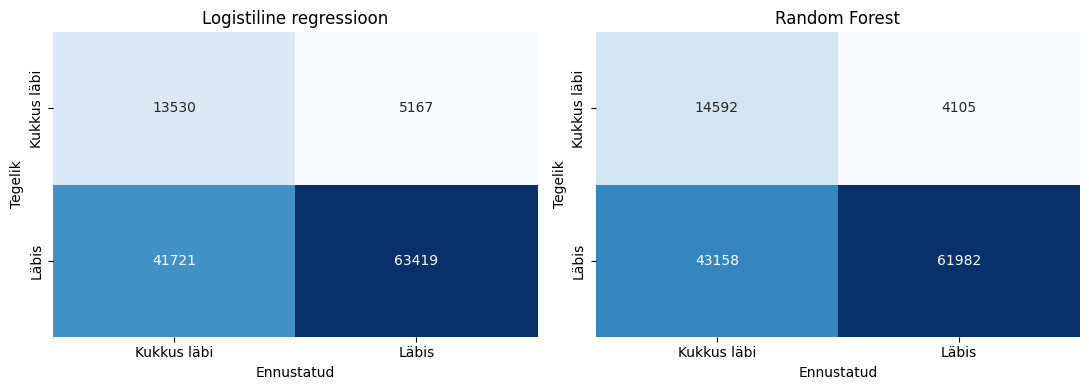

In [35]:
def plot_confusion_matrices(cm1, cm2, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, cm, title in zip(axes, [cm1, cm2], [title1, title2]):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Kukkus läbi', 'Läbis'],
                    yticklabels=['Kukkus läbi', 'Läbis'])
        ax.set(xlabel='Ennustatud', ylabel='Tegelik', title=title)
    plt.tight_layout()
    plt.show()

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plot_confusion_matrices(cm_lr, cm_rf, 'Logistiline regressioon', 'Random Forest')

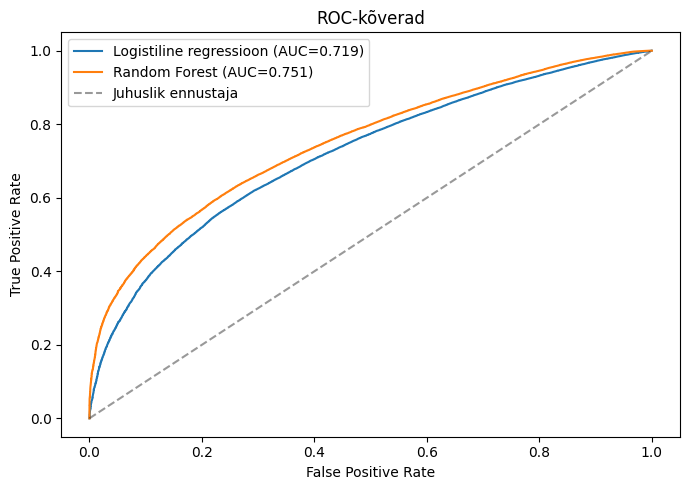

In [36]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, label=f'Logistiline regressioon (AUC={results[0]["roc_auc"]:.3f})')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={results[1]["roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Juhuslik ennustaja')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC-kõverad')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

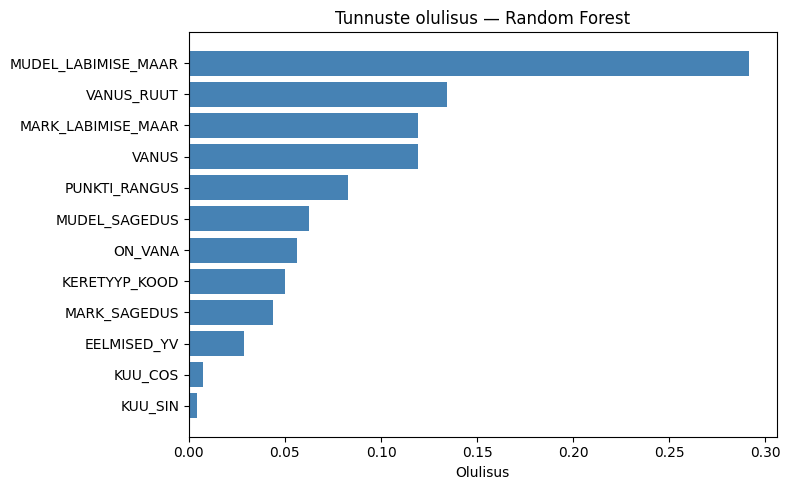

Top 3 olulisimat tunnust:
  MUDEL_LABIMISE_MAAR: 0.2913
  VANUS_RUUT: 0.1346
  MARK_LABIMISE_MAAR: 0.1194


In [37]:
importance_df = pd.DataFrame({
    'tunnus':   FEATURE_COLS,
    'olulisus': model.feature_importances_
}).sort_values('olulisus', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['tunnus'], importance_df['olulisus'], color='steelblue')
ax.set(xlabel='Olulisus', title='Tunnuste olulisus — Random Forest')
plt.tight_layout()
plt.show()

print('Top 3 olulisimat tunnust:')
for _, row in importance_df.tail(3).iloc[::-1].iterrows():
    print(f'  {row["tunnus"]}: {row["olulisus"]:.4f}')

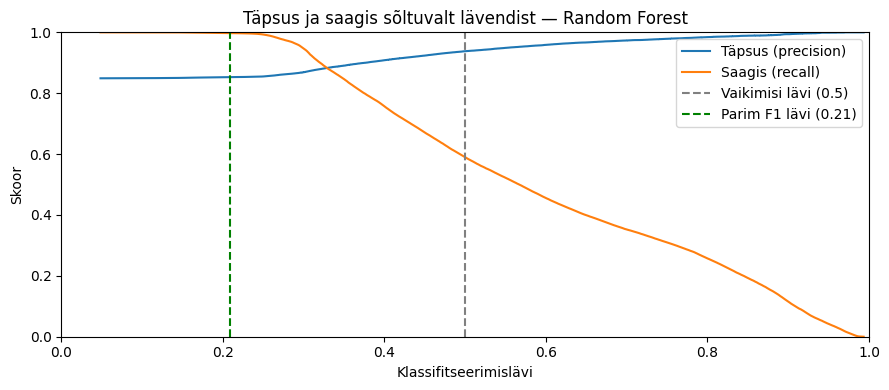

Parim lävi F1 järgi: 0.209  (täpsus=0.853, saagis=0.998, F1=0.920)


In [38]:
# Täpsus ja saagis sõltuvalt klassifitseerimislävest (Random Forest)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precisions[:-1], label='Täpsus (precision)')
ax.plot(thresholds, recalls[:-1],    label='Saagis (recall)')
ax.axvline(0.5,                    color='gray',  linestyle='--', label='Vaikimisi lävi (0.5)')
ax.axvline(thresholds[best_idx],   color='green', linestyle='--',
           label=f'Parim F1 lävi ({thresholds[best_idx]:.2f})')
ax.set(xlabel='Klassifitseerimislävi', ylabel='Skoor',
       title='Täpsus ja saagis sõltuvalt lävendist — Random Forest',
       xlim=(0, 1), ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

print(f'Parim lävi F1 järgi: {thresholds[best_idx]:.3f}  '
      f'(täpsus={precisions[best_idx]:.3f}, saagis={recalls[best_idx]:.3f}, '
      f'F1={f1_scores[best_idx]:.3f})')

In [39]:
model_path = MODEL_DIR / 'random_forest.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# Build mark and model lookup tables for the dashboard
mark_lookup = {}
for mark, grp in df.groupby('MARK'):
    if pd.notna(mark) and str(mark).strip():
        mark_lookup[str(mark)] = {
            'sagedus': int(grp['MARK_SAGEDUS'].iloc[0]),
            'labimise_maar': float(grp['MARK_LABIMISE_MAAR'].iloc[0]),
        }

mudel_lookup = {}
for (mark, mudel), grp in df.groupby(['MARK', 'MUDEL']):
    if pd.notna(mark) and pd.notna(mudel) and str(mark).strip() and str(mudel).strip():
        if str(mark) not in mudel_lookup:
            mudel_lookup[str(mark)] = {}
        mudel_lookup[str(mark)][str(mudel)] = {
            'sagedus': int(grp['MUDEL_SAGEDUS'].iloc[0]),
            'labimise_maar': float(grp['MUDEL_LABIMISE_MAAR'].iloc[0]),
        }

meta = {
    'features':           FEATURE_COLS,
    'metrics':            {k: v for k, v in results[1].items() if k != 'mudel'},
    'best_params':        clf.best_params_,
    'feature_importance': importance_df.rename(
        columns={'tunnus': 'feature', 'olulisus': 'importance'}
    ).to_dict('records'),
    'train_year': 2025,
    'train_rows': len(X_train),
    'mark_lookup':  mark_lookup,
    'mudel_lookup': mudel_lookup,
}
meta_path = MODEL_DIR / 'model_metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f'✓ Mudel salvestatud:    {model_path}')
print(f'✓ Metaandmed:           {meta_path}  ({meta_path.stat().st_size // 1024} KB)')
print(f'  Margid: {len(mark_lookup)}, mudelid kokku: {sum(len(v) for v in mudel_lookup.values())}')
print(f'✓ Klastrite profiilid:  {profiles_path}')
print(f'\nDashboard: streamlit run dashboard/app.py')

Task was destroyed but it is pending!
task: <Task pending name='Task-120' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/op/.local/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-121' coro=<Kernel.shell_main() running at /home/op/.local/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/op/.local/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-121' coro=<Kernel.shell_main() running at /home/op/.local/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


✓ Mudel salvestatud:    /home/op/Documents/Projektid/Andmeteadus_kodutoo/models/random_forest.pkl
✓ Metaandmed:           /home/op/Documents/Projektid/Andmeteadus_kodutoo/models/model_metadata.json  (2367 KB)
  Margid: 2516, mudelid kokku: 22232
✓ Klastrite profiilid:  /home/op/Documents/Projektid/Andmeteadus_kodutoo/data/processed/cluster_profiles.json

Dashboard: streamlit run dashboard/app.py


## Kokkuvõte

### 4.2 — K-Means klasterdamine
- Tunnused skaleeritud StandardScaler-iga; optimaalne k leitud küünarnuki- ja siluetimeetodiga
- Klastrid eristavad vanu vs uusi autosid ning leebeid vs rangeid ülevaatuspunkte

### 4.3 — Klassifikaatorite võrdlus
- Andmestik on **tugevalt tasakaalustamata** (84% positiivseid) 
- Mõlemad mudelid kasutavad `class_weight='balanced'`; hindamine ROC-AUC ja F1 järgi
- **Random Forest** ületab logistilist regressiooni nii ROC-AUC kui F1 järgi
- Random Foresti parameetrid leiti GridSearchCV-ga (alamvalim 50 000 rida, 3-kordne CV)
- Klassifitseerimisläve muutes saab täpsust ja saagist tasakaalustada vastavalt kasutuse eesmärgile